In [45]:
import numpy as np
import scipy as sp
from numpy import log, cosh, sqrt, zeros, linspace, ones, exp, argmin
import matplotlib.pyplot as plt
from matplotlib.pyplot import gca
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn, factorial
import warnings
warnings.filterwarnings('ignore')

In [12]:
Rs = np.linspace(2, 256, 255)
epsilon_F = 0.4
alpha = 1/137
epsilon_1 = epsilon_2 = 1

In [41]:
hbar_omegas = zeros((5, (len(Rs))))
for (i, l) in enumerate(range(1, 6)):
    hbar_omegas[i, :] = sqrt(l*(l+1)*alpha*800*epsilon_F/(l*epsilon_1+(l+1)*epsilon_2)/Rs)/epsilon_F; #Intraband only approximation

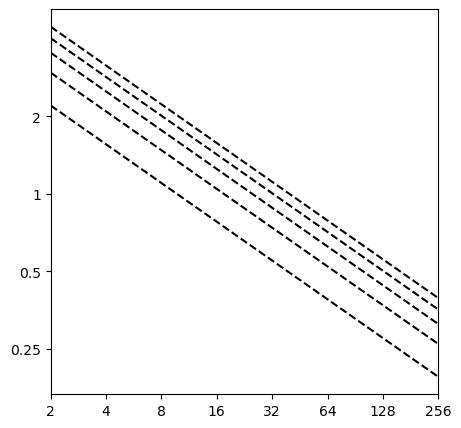

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, 5):
    ax.plot(log(Rs), log(hbar_omegas[i, :]), color="black", linestyle="dashed" )
plt.gca().set_xlim(log(2), log(256))
plt.gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
plt.gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);

## In the below, we introduce the interband contribution

In [213]:
R_range = np.linspace(2, 256, 255)
hbar_omega_range = epsilon_F * np.linspace(0.01, 2, 400)
dispersion = zeros((5, len(R_range)))

for (i, l) in enumerate(range(1, 6)):
    lhs = R_range*(epsilon_1/(l+1)+epsilon_2/l)
    rhs = (800 * alpha)/(hbar_omega_range)*(epsilon_F/hbar_omega_range+(1/4)*log(abs((2*epsilon_F-hbar_omega_range)/(2*epsilon_F+hbar_omega_range))))
    dispersion[i, :] = hbar_omega_range[np.argmin(log(abs(lhs.reshape(255, 1 ).repeat(400, 1) - rhs.reshape(1, 400).repeat(255, 0))), 1)]

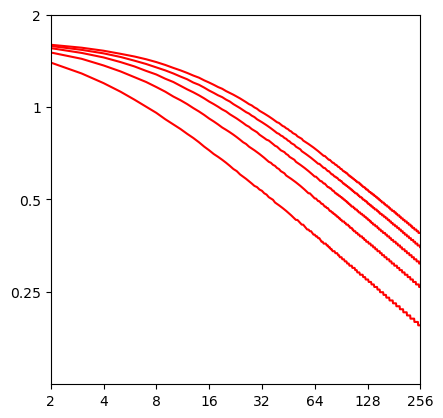

In [214]:
for i in range(0, 5): 
    plt.plot(log(R_range), log(dispersion[i, :]/epsilon_F), color="red")
gca().set_xlim(log(2), log(256))
gca().set_ylim(log(0.125), log(2))

gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
gca().set_aspect((log(256)-log(2))/(log(2)-log(0.125)))

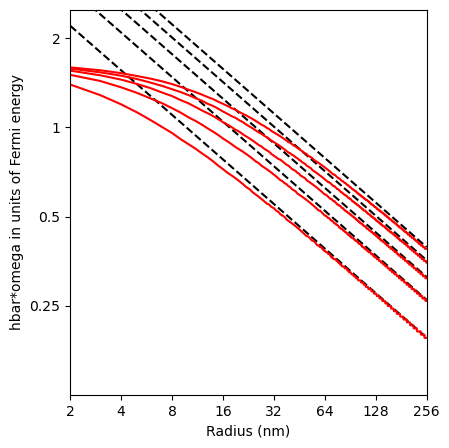

In [218]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, 5):
    ax.plot(log(Rs), log(hbar_omegas[i, :]), color="black", linestyle="dashed" )
    ax.plot(log(R_range), log(dispersion[i, :]/epsilon_F), color="red")
gca().set_xlim(log(2), log(256))
gca().set_ylim(log(0.125), log(2.5))

gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
gca().set_aspect((log(256)-log(2))/(log(2)-log(0.125)))
gca().set_xlabel("Radius (nm)");
gca().set_ylabel("hbar*omega in units of Fermi energy");

In the below, we find the crossover pointn where g(omega) changes sign. 

In [79]:
x = linspace(0.1, 1, 10000)
y = exp(4*x)-abs((2*x+1)/(2*x-1))

In [85]:
print(f"omega/fermi_energy: {1/x[argmin(abs(y))]}")

omega/fermi_energy: 1.6671668667466986


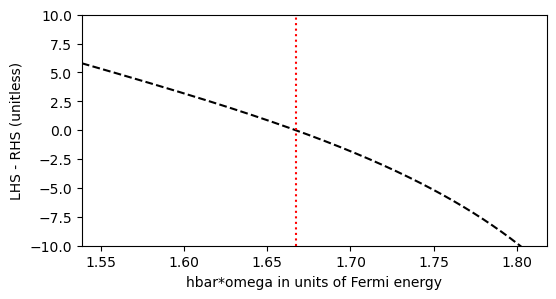

In [96]:
fig, ax = plt.subplots(figsize=(6, 3))
plt.plot(1 / x, y, color="black", linestyle="dashed")
plt.ylim(-10, 10);
plt.xlim(1/0.65, 1/0.55);
plt.xlabel("hbar*omega in units of Fermi energy")
plt.ylabel("LHS - RHS (unitless)");
plt.vlines([1/x[argmin(abs(y))]], -10, 10, linestyle="dotted", color="red");